In [1]:
import torch
import string
import unicodedata

if torch.cuda.is_available():
    device = torch.device('cuda')
    print(f"GPU: {torch.cuda.get_device_name(0)} is available.")
else:
    device = torch.device('cpu')
    print("No GPU available. Training will run on CPU.")

GPU: NVIDIA GeForce RTX 4080 SUPER is available.


In [2]:
allowed_characters = string.ascii_letters + " .,;'" + "_"
n_letters = len(allowed_characters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in allowed_characters
    )

In [3]:
def letterToIndex(letter):
    # return our out-of-vocabulary character if we encounter a letter unknown to our model
    if letter not in allowed_characters:
        return allowed_characters.find("_")
    else:
        return allowed_characters.find(letter)

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

In [4]:
from io import open
import glob
import os
import time

import torch
from torch.utils.data import Dataset

class NamesDataset(Dataset):

    def __init__(self, data_dir):
        self.data_dir = data_dir #for provenance of the dataset
        self.load_time = time.localtime #for provenance of the dataset
        labels_set = set() #set of all classes

        self.data = []
        self.data_tensors = []
        self.labels = []
        self.labels_tensors = []

        #read all the ``.txt`` files in the specified directory
        text_files = glob.glob(os.path.join(data_dir, '*.txt'))
        for filename in text_files:
            label = os.path.splitext(os.path.basename(filename))[0]
            labels_set.add(label)
            lines = open(filename, encoding='utf-8').read().strip().split('\n')
            for name in lines:
                self.data.append(name)
                self.data_tensors.append(lineToTensor(name))
                self.labels.append(label)

        #Cache the tensor representation of the labels
        self.labels_uniq = list(labels_set)
        for idx in range(len(self.labels)):
            temp_tensor = torch.tensor([self.labels_uniq.index(self.labels[idx])], dtype=torch.long)
            self.labels_tensors.append(temp_tensor)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        data_item = self.data[idx]
        data_label = self.labels[idx]
        data_tensor = self.data_tensors[idx]
        label_tensor = self.labels_tensors[idx]

        return label_tensor, data_tensor, data_label, data_item

In [5]:
alldata = NamesDataset("data/names")
train_set, test_set = torch.utils.data.random_split(alldata, [.85, .15], generator=torch.Generator().manual_seed(2024))

print(f"train examples = {len(train_set)}, validation examples = {len(test_set)}")

train examples = 17063, validation examples = 3011


In [6]:
import torch.nn as nn
import torch.nn.functional as F

class charGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, dropout_prob=0.3):
        super(charGRU, self).__init__()

        self.rnn = nn.GRU(input_size, hidden_size, bidirectional=True, dropout=dropout_prob)
        self.h2o = nn.Linear(hidden_size * 2, output_size)
        self.dropout = nn.Dropout(dropout_prob)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, line_tensor):
        rnn_out, hidden = self.rnn(line_tensor)
        final_hidden = torch.cat((hidden[0], hidden[1]), dim=1)
        dropped = self.dropout(final_hidden)
        output = self.h2o(dropped)
        output = self.softmax(output)

        return output

In [7]:
n_hidden = 256
rnn = charGRU(n_letters, n_hidden, len(alldata.labels_uniq)).to(device)
print(rnn)

charGRU(
  (rnn): GRU(58, 256, dropout=0.3, bidirectional=True)
  (h2o): Linear(in_features=512, out_features=18, bias=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (softmax): LogSoftmax(dim=1)
)


/home/sraja/miniconda3/envs/pytorch/lib/python3.12/site-packages/torch/nn/modules/rnn.py:123: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.3 and num_layers=1
  warnings.warn(


In [8]:
def label_from_output(output, output_labels):
    top_n, top_i = output.topk(1)
    label_i = top_i[0].item()
    return output_labels[label_i], label_i

input = lineToTensor('Albert').to(device)  # Convert input to tensor and move to device
output = rnn(input) #this is equivalent to ``output = rnn.forward(input)``
print(output)
print(label_from_output(output, alldata.labels_uniq))

tensor([[-2.8953, -2.9509, -2.8763, -2.8563, -2.8350, -2.8660, -2.9282, -2.8637,
         -2.8465, -2.8804, -2.9220, -2.9242, -2.9148, -2.8612, -2.8601, -2.9458,
         -2.8661, -2.9459]], device='cuda:0', grad_fn=<LogSoftmaxBackward0>)
('French', 4)


In [ ]:
import random
import numpy as np

from sklearn.metrics import accuracy_score

def train(rnn, training_data, n_epoch=15, n_batch_size=64, report_every=1, learning_rate=0.5, criterion=nn.NLLLoss()):
    current_loss = 0
    all_losses = []
    rnn.train()
    optimizer = torch.optim.SGD(rnn.parameters(), lr=learning_rate)

    print(f"training on data set with n = {len(training_data)}")

    for epoch in range(1, n_epoch + 1):
        correct, total = 0, 0
        y_true, y_pred = [], []

        training_data = list(training_data)
        random.shuffle(training_data)
        batches = np.array_split(range(len(training_data)), len(training_data) // n_batch_size)

        for batch in batches:
            batch_loss = 0
            for i in batch:
                label_tensor, text_tensor, label, _ = training_data[i]
                label_tensor = label_tensor.to(device)
                text_tensor = text_tensor.to(device)
                output = rnn(text_tensor)
                loss = criterion(output, label_tensor)
                batch_loss += loss

                # Accuracy calculation
                _, pred_idx = output.topk(1)
                y_pred.append(pred_idx.item())
                y_true.append(label_tensor.item())

            batch_loss.backward()
            nn.utils.clip_grad_norm_(rnn.parameters(), 3)
            optimizer.step()
            optimizer.zero_grad()

            current_loss += batch_loss.item() / len(batch)

        epoch_loss = current_loss / len(batches)
        accuracy = accuracy_score(y_true, y_pred)
        all_losses.append(epoch_loss)
        if epoch % report_every == 0:
            print(f"Epoch {epoch} | Loss: {epoch_loss:.4f} | Accuracy: {accuracy*100:.2f}%")

        current_loss = 0

    return all_losses

In [10]:
start = time.time()
all_losses = train(rnn, train_set)
end = time.time()
print(f"training took {end-start}s")

training on data set with n = 17063
Epoch 1 | Loss: 1.3766 | Accuracy: 58.13%
Epoch 2 | Loss: 1.0219 | Accuracy: 68.09%
Epoch 3 | Loss: 0.8762 | Accuracy: 72.53%
Epoch 4 | Loss: 0.7883 | Accuracy: 75.54%
Epoch 5 | Loss: 0.7261 | Accuracy: 77.91%
Epoch 6 | Loss: 0.6672 | Accuracy: 79.44%
Epoch 7 | Loss: 0.6322 | Accuracy: 80.49%
Epoch 8 | Loss: 0.5883 | Accuracy: 81.67%
Epoch 9 | Loss: 0.5556 | Accuracy: 82.53%
Epoch 10 | Loss: 0.5149 | Accuracy: 83.78%
Epoch 11 | Loss: 0.4801 | Accuracy: 85.24%
Epoch 12 | Loss: 0.4498 | Accuracy: 85.63%
Epoch 13 | Loss: 0.4168 | Accuracy: 86.66%
Epoch 14 | Loss: 0.3977 | Accuracy: 87.24%
Epoch 15 | Loss: 0.3653 | Accuracy: 88.13%
training took 346.93567967414856s


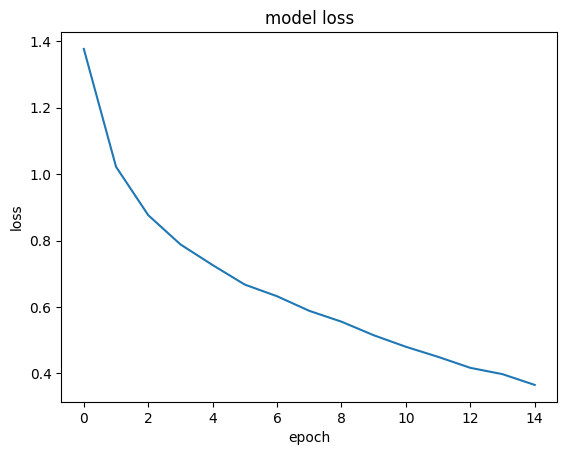

In [16]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure()
plt.plot(all_losses)
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.show()

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate(model, test_data, labels_uniq):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for label_tensor, text_tensor, label, _ in test_data:
            label_tensor = label_tensor.to(device)
            text_tensor = text_tensor.to(device)
            output = model(text_tensor)
            _, predicted_idx = output.topk(1)
            y_true.append(label_tensor.item())
            y_pred.append(predicted_idx.item())

    accuracy = accuracy_score(y_true, y_pred)
    print(f"\nEvaluation Accuracy: {accuracy * 100:.2f}%")

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_uniq)
    dfig, ax = plt.subplots(figsize=(12, 12))  # Increase width/height
    disp.plot(ax=ax, cmap='Blues', xticks_rotation=90, values_format='d')
    # Tweak font sizes
    plt.xticks(fontsize=10)
    plt.yticks(fontsize=10)
    plt.title(f"Confusion Matrix (Accuracy: {accuracy*100:.2f}%)", fontsize=14)
    plt.xlabel("Predicted label", fontsize=12)
    plt.ylabel("True label", fontsize=12)
    plt.tight_layout()
    plt.show()


Evaluation Accuracy: 82.00%


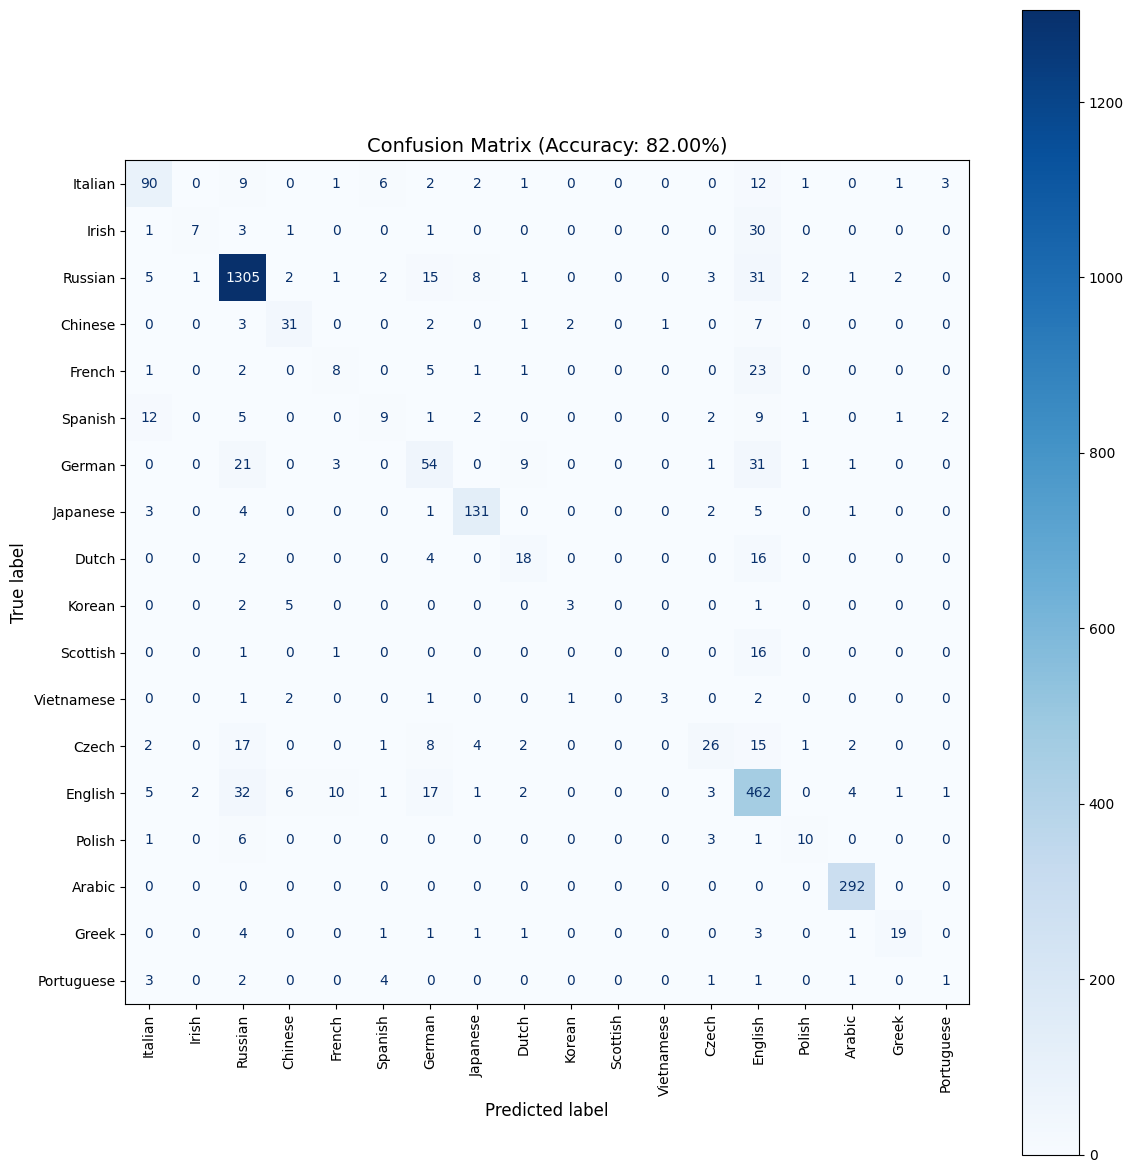

In [14]:
evaluate(rnn, test_set, alldata.labels_uniq)